# Canteen Management system

In [ ]:
pip install openpyxl

In [ ]:
import json
import pandas as pd

# Load JSON
with open("./assets/Canteen/canteen-management.json", "r") as f:
    data = json.load(f)

# Items table
items = []
for pid, p in data.get("products", {}).items():
    items.append({
        "item_id": p.get("id", pid),
        "name": p.get("name"),
        "price": p.get("price"),
        "initial_price": p.get("initialPrice") or p.get("initialPrices"),
        "stock_quantity": p.get("quantity")
    })

df_items = pd.DataFrame(items)

# Users table
users = {}
for date, sales in data.get("sales", {}).items():
    for sid, s in sales.items():
        uid = s.get("userId")
        if uid and uid not in users:
            users[uid] = {
                "user_id": uid,
                "email": s.get("userEmail")
            }

df_users = pd.DataFrame(users.values())

# Sales table (fact table)
sales_rows = []
for date, sales in data.get("sales", {}).items():
    for sid, s in sales.items():
        if "items" in s:
            for it in s["items"]:
                sales_rows.append({
                    "sale_id": sid,
                    "date": date,
                    "user_id": s.get("userId"),
                    "item_id": it.get("id"),
                    "quantity_sold": it.get("quantity", 0),
                    "unit_price": it.get("price", 0),
                    "line_total": it.get("quantity", 0) * it.get("price", 0),
                    "bill_total": s.get("total")
                })

df_sales = pd.DataFrame(sales_rows)

# Join: sales + users
df_sales_users = pd.merge(
    df_sales,
    df_users,
    on="user_id",
    how="left"
)

# Join: + items
df_full = pd.merge(
    df_sales_users,
    df_items,
    on="item_id",
    how="left",
    suffixes=("_sale", "_item")
)

# Write Excel
path = "./assets/Canteen/canteen_database.xlsx"
with pd.ExcelWriter(path, engine="openpyxl") as writer:
    df_items.to_excel(writer, sheet_name="items", index=False)
    df_users.to_excel(writer, sheet_name="users", index=False)
    df_sales.to_excel(writer, sheet_name="sales", index=False)
    df_full.to_excel(writer, sheet_name="sales_full", index=False)

print(f"Excel database created at: {path}")


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Read Excel
path = "./assets/Canteen/canteen_database.xlsx"
df = pd.read_excel(path, sheet_name="sales_full")

# Ensure date is datetime
df["date"] = pd.to_datetime(df["date"])

In [26]:
# 1. Best selling item (by quantity sold)
best_selling = (
    df.groupby("name")["quantity_sold"]
    .sum()
    .sort_values(ascending=False)
)

print("Best selling items:")
print(best_selling.head(1))

Best selling items:
name
Sandwich    177
Name: quantity_sold, dtype: int64


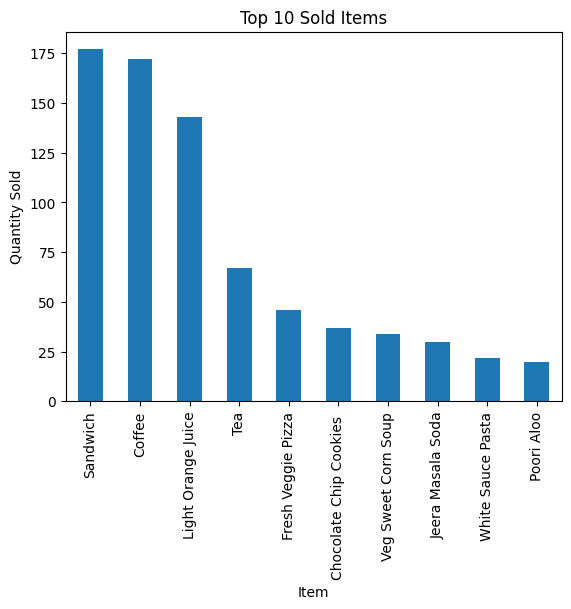

name
Sandwich                   177
Coffee                     172
Light Orange Juice         143
Tea                         67
Fresh Veggie Pizza          46
Chocolate Chip Cookies      37
Veg Sweet Corn Soup         34
Jeera Masala Soda           30
White Sauce Pasta           22
Poori Aloo                  20
Name: quantity_sold, dtype: int64


In [27]:
# 2. Top 10 sold items
plt.figure()
best_selling.head(10).plot(kind="bar")
plt.title("Top 10 Sold Items")
plt.ylabel("Quantity Sold")
plt.xlabel("Item")
plt.show()

print(best_selling.head(10))

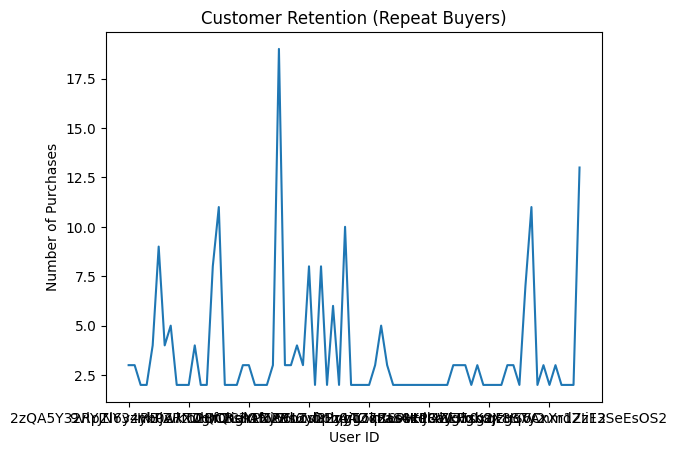


Repeat customers:
user_id
P3E2dGFgy9dBbz3gzDgy5c4fzlC2    19
zwON2oBPv9SOgCKgGhOXwW5NgTW2    13
FsqWcflTedg7MMDNcTl1Nac6D9M2    11
wKvl0TuXUZWPIpvu5qQ0Cz3UU0L2    11
XEqOYXlxrXaHhENr12XzEgEUUBm1    10
                                ..
wQHF1Ts8PwTwfO5K6498kO3Fpcr2     2
xhEFr0xqFHS6Cnm12IiF3SeEsOS2     2
xiUuqS26zcYqvh8WlKSM5V5rYmn1     2
ybPzeD8X73YpGpgjq3iy0MskZSq1     2
zKNqTDll5BP0pynXEoiQqiinZDh1     2
Name: sale_id, Length: 76, dtype: int64


In [ ]:
# 3. Customer retention
# Users who purchased more than once
user_purchase_count = df.groupby("user_id")["sale_id"].nunique()
retained_users = user_purchase_count[user_purchase_count > 1]

plt.figure()
retained_users.plot(kind="bar")
plt.title("Customer Retention (Repeat Buyers)")
plt.ylabel("Number of Purchases")
plt.xlabel("User ID")
plt.show()

print("\nRepeat customers:")
print(retained_users.sort_values(ascending=False))

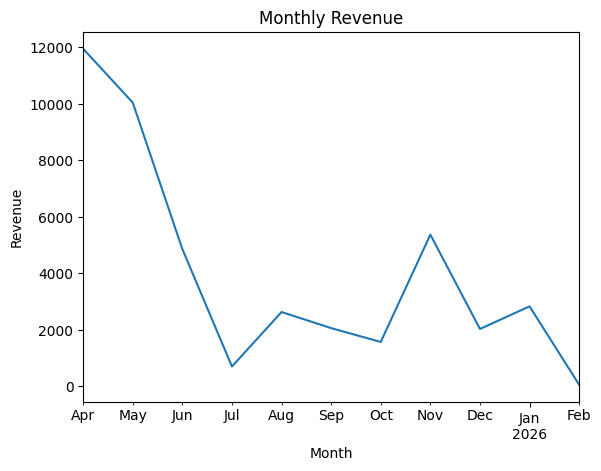


Monthly revenue:
month
2025-04    11951
2025-05    10042
2025-06     4854
2025-07      695
2025-08     2625
2025-09     2055
2025-10     1565
2025-11     5366
2025-12     2025
2026-01     2825
2026-02       50
Freq: M, Name: line_total, dtype: int64


In [29]:
# 4. Monthly revenue
df["month"] = df["date"].dt.to_period("M")
monthly_revenue = df.groupby("month")["line_total"].sum()

plt.figure()
monthly_revenue.plot(kind="line")
plt.title("Monthly Revenue")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.show()

print("\nMonthly revenue:")
print(monthly_revenue)

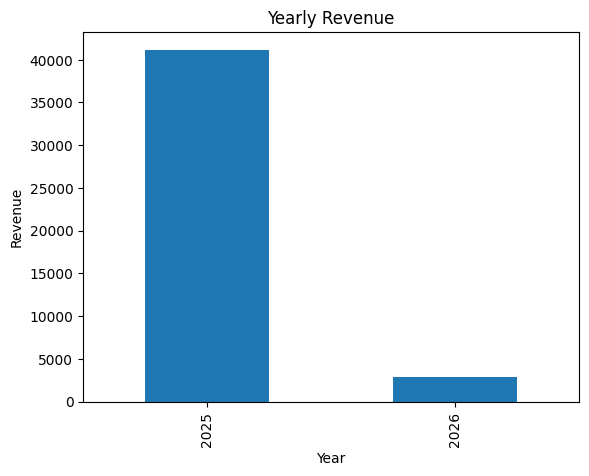


Yearly revenue:
year
2025    41178
2026     2875
Name: line_total, dtype: int64


In [30]:
# 5. Yearly revenue
df["year"] = df["date"].dt.year
yearly_revenue = df.groupby("year")["line_total"].sum()

plt.figure()
yearly_revenue.plot(kind="bar")
plt.title("Yearly Revenue")
plt.ylabel("Revenue")
plt.xlabel("Year")
plt.show()

print("\nYearly revenue:")
print(yearly_revenue)

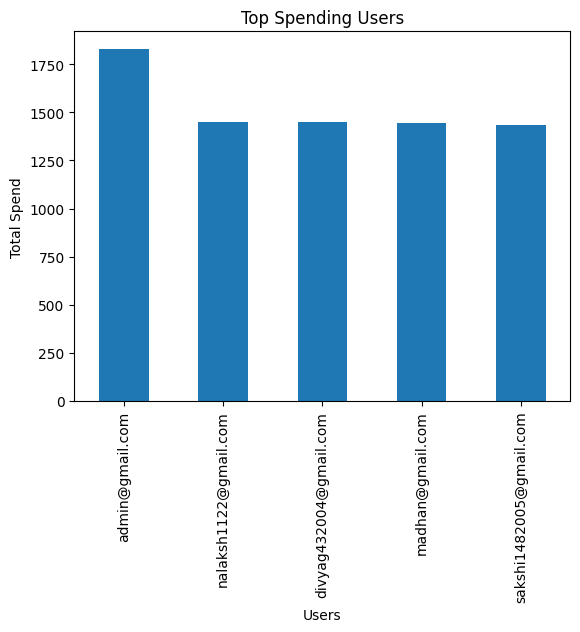


Top spending user:
email
admin@gmail.com            1829
nalaksh1122@gmail.com      1452
divyag432004@gmail.com     1450
madhan@gmail.com           1445
sakshi1482005@gmail.com    1435
Name: line_total, dtype: int64


In [33]:
# 6. User who bought the most (total spend)
top_user = (
    df.groupby("email")["line_total"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure()
top_user.head(5).plot(kind="bar")
plt.title("Top Spending Users")
plt.ylabel("Total Spend")
plt.xlabel("Users")
plt.show()

print("\nTop spending user:")
print(top_user.head(5))